# PCA i LDA

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

sns.set_theme(style='whitegrid')
np.set_printoptions(precision=4, suppress=True)

In [20]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='class_id')
class_names = iris.target_names

display(X.head())
print('Ksztalt X:', X.shape)
print('Liczba klas:', y.nunique())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Ksztalt X: (150, 4)
Liczba klas: 3


In [21]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Krok 2: macierz kowariancji dla danych standaryzowanych
cov_matrix = np.cov(X_std.T)
print('Macierz kowariancji:')
print(cov_matrix)

# Krok 3: rozklad wlasny
eig_values, eig_vectors = np.linalg.eig(cov_matrix)

# Krok 4: sortowanie malejaco po wartosciach wlasnych
sorted_idx = np.argsort(eig_values)[::-1]
eig_values = eig_values[sorted_idx]
eig_vectors = eig_vectors[:, sorted_idx]

explained_ratio = eig_values / eig_values.sum()

print('\nWartosci wlasne (posortowane):')
print(eig_values)
print('\nUdzial wariancji [%]:')
print(np.round(explained_ratio * 100, 2))

# Krok 5: projekcja do 2D
V2 = eig_vectors[:, :2]
Y_pca_manual = X_std @ V2

pca_manual_df = pd.DataFrame(Y_pca_manual, columns=['PC1_manual', 'PC2_manual'])
pca_manual_df['class_id'] = y.values
display(pca_manual_df.head())

Macierz kowariancji:
[[ 1.0067 -0.1184  0.8776  0.8234]
 [-0.1184  1.0067 -0.4313 -0.3686]
 [ 0.8776 -0.4313  1.0067  0.9693]
 [ 0.8234 -0.3686  0.9693  1.0067]]

Wartosci wlasne (posortowane):
[2.9381 0.9202 0.1477 0.0209]

Udzial wariancji [%]:
[72.96 22.85  3.67  0.52]


,PC1_manual,PC2_manual,class_id
0,-2.264703,-0.480027,0
1,-2.080961,0.674134,0
2,-2.364229,0.341908,0
3,-2.299384,0.597395,0
4,-2.389842,-0.646835,0


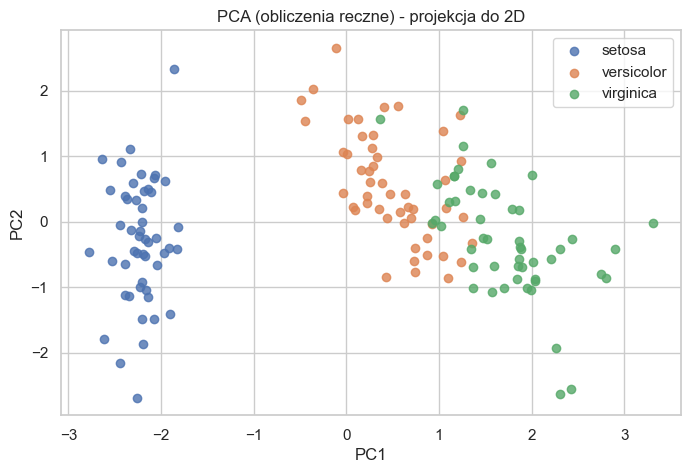

In [22]:
plt.figure(figsize=(8, 5))
for class_id, class_name in enumerate(class_names):
    mask = pca_manual_df['class_id'] == class_id
    plt.scatter(
        pca_manual_df.loc[mask, 'PC1_manual'],
        pca_manual_df.loc[mask, 'PC2_manual'],
        label=class_name,
        alpha=0.8
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (obliczenia reczne) - projekcja do 2D')
plt.legend()
plt.show()

In [23]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['class_id'] = y.values

print('Explained variance ratio (PCA sklearn):', np.round(pca.explained_variance_ratio_, 4))
print('Suma dla 2 skladowych:', np.round(pca.explained_variance_ratio_.sum(), 4))
display(pca_df.head())

Explained variance ratio (PCA sklearn): [0.7296 0.2285]
Suma dla 2 skladowych: 0.9581


,PC1,PC2,class_id
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


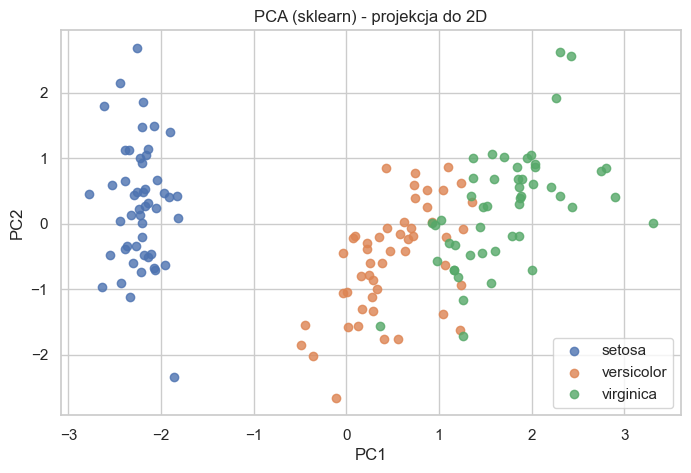

In [24]:
plt.figure(figsize=(8, 5))
for class_id, class_name in enumerate(class_names):
    mask = pca_df['class_id'] == class_id
    plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'], label=class_name, alpha=0.8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (sklearn) - projekcja do 2D')
plt.legend()
plt.show()

In [25]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_std, y)

lda_df = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
lda_df['class_id'] = y.values
display(lda_df.head())

,LD1,LD2,class_id
0,8.061800,-0.300421,0
1,7.128688,0.786660,0
2,7.489828,0.265384,0
3,6.813201,0.670631,0
4,8.132309,-0.514463,0


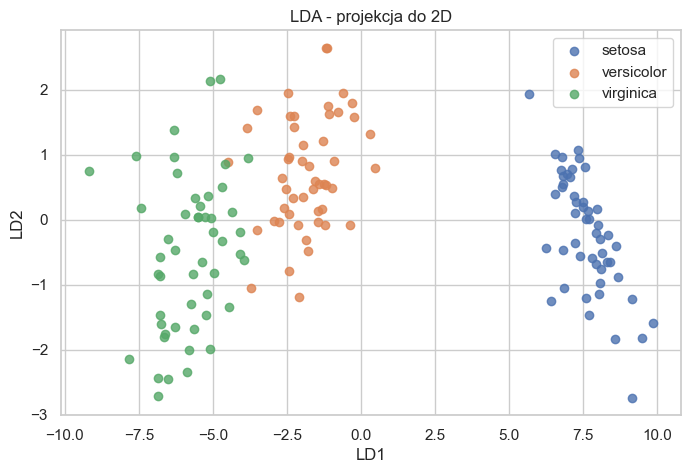

In [26]:
plt.figure(figsize=(8, 5))
for class_id, class_name in enumerate(class_names):
    mask = lda_df['class_id'] == class_id
    plt.scatter(lda_df.loc[mask, 'LD1'], lda_df.loc[mask, 'LD2'], label=class_name, alpha=0.8)

plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA - projekcja do 2D')
plt.legend()
plt.show()